# Freight Rate Prediction - Data Exploration, Validation & Modeling


### Import Libraries and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set design aesthetics for visualizations
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

### Load the Datasets

In [2]:
train_df = pd.read_csv('data/train-test.csv')
val_df = pd.read_csv('data/validation.csv')
dec_df = pd.read_csv('data/december-chart-inputs.csv')

print(f"Training shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"December inputs shape: {dec_df.shape}")
train_df.head()

Training shape: (48000, 14)
Validation shape: (12000, 13)
December inputs shape: (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [34]:
val_df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [33]:
dec_df.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate,market_index,quote_signal
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,812.149040,0.834919,2.052023
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,822.263119,0.914680,2.034115
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,841.005559,0.994063,2.053293
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,845.114302,1.024021,2.065683
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,834.381672,0.975120,2.047368


### Inference:
1. **Dimensions:** The training set has 48,000 records across 14 columns. The validation set has 12,000 records across 13 columns (missing the target `posted_rate`).
2. **Column types:** Columns include categoricals (`pickup`, `delivery`, `equipment`), coordinates (`pickup_lat`, `pickup_lon`, `delivery_lat`, `delivery_lon`), numericals (`distance`, `weight`, `market_index`, `quote_signal`), and dates (`date`).
3. **December Scenario:** The December inputs file contains dates from 2025-12-01 to 2025-12-31, but lacks coordinate fields, `market_index`, or `quote_signal` columns.

### Check for Categorical features

In [3]:
cat_cols = ["pickup", 'delivery', 'equipment']
num_cols = ['distance', 'weight', 'market_index', 'quote_signal']

for col in cat_cols:
    print(f"{col}: {train_df[col].unique()}")

pickup: ['Richmond' 'Philadelphia' 'Hartford' 'Dallas' 'Phoenix' 'Fresno'
 'San Francisco' 'Bakersfield' 'Albuquerque' 'Harrisburg' 'Mobile'
 'Nashville' 'Detroit' 'Albany' 'New Orleans' 'Reno' 'Austin'
 'Chattanooga' 'Cincinnati' 'Syracuse' 'Atlanta' 'Oklahoma City'
 'Lexington' 'Los Angeles' 'Providence' 'Madison' 'El Paso' 'Washington'
 'Amarillo' 'Green Bay' 'Memphis' 'Baton Rouge' 'Kansas City' 'Fort Wayne'
 'Charleston' 'Columbia' 'Grand Rapids' 'Jacksonville' 'Corpus Christi'
 'Birmingham' 'Milwaukee' 'Tampa' 'Raleigh' 'Indianapolis' 'Baltimore'
 'Boston' 'San Antonio' 'Montgomery' 'Buffalo' 'New York' 'Houston'
 'Dayton' 'Toledo' 'Greensboro' 'Tulsa' 'Savannah' 'Shreveport' 'Lubbock'
 'St. Louis' 'Little Rock' 'Louisville' 'Salt Lake City' 'Las Vegas'
 'Tucson']
delivery: ['Baltimore' 'Philadelphia' 'Green Bay' 'Atlanta' 'Nashville'
 'Corpus Christi' 'San Antonio' 'Kansas City' 'Montgomery' 'Phoenix'
 'Fresno' 'Lexington' 'El Paso' 'Syracuse' 'Louisville' 'Baton Rouge'
 'Bakers

### Check for Missing Values

In [4]:
print("> Missing values in Training")
print(train_df.isnull().sum())
print("\n>Missing values in Validation")
print(val_df.isnull().sum())

> Missing values in Training
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

>Missing values in Validation
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64


### Inference:
*   **Missing values:** missing values in both `weight` (300 in train, 165 in validation) and `market_index` (374 in train, 249 in validation).
*   **Handling `weight`:** Since different equipment types (Dry Van, Flatbed, Reefer) carry different loads on average, impute missing weights with the median weight of the corresponding equipment type.
*   **Handling `market_index`:** Since market state represents temporal market demand, impute missing market indices with the overall median or a time-based interpolation.

### Explore the Target Variable (`posted_rate`)

check for distribution

In [30]:
train_df['posted_rate'].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

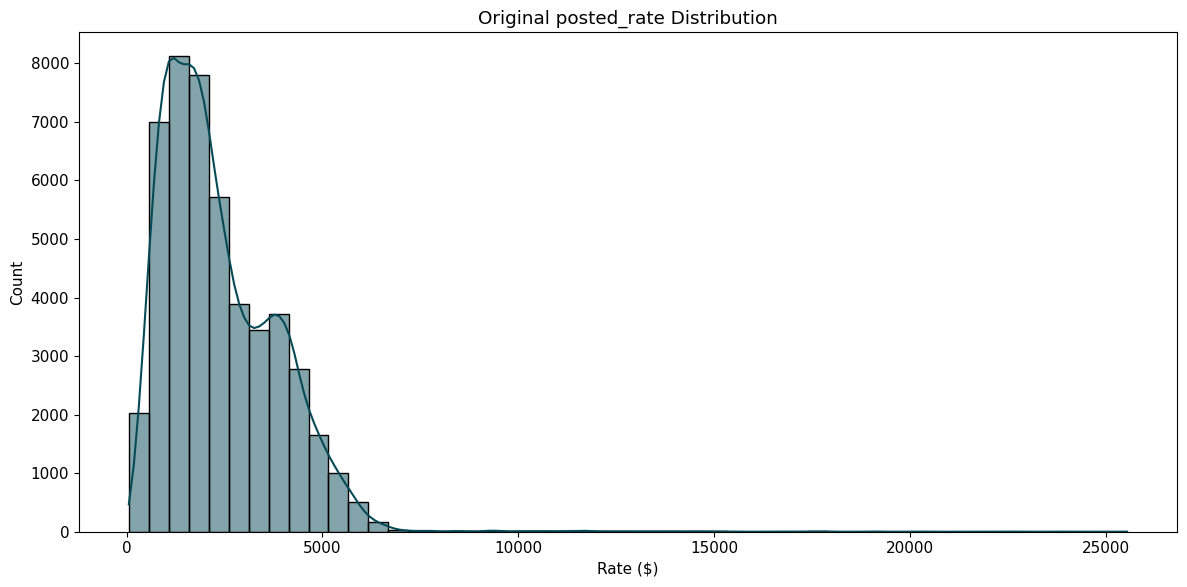

In [28]:
# Original scale
sns.histplot(train_df['posted_rate'], bins=50, kde=True, color='#064A56')
plt.title('Original posted_rate Distribution')
plt.xlabel('Rate ($)')


plt.tight_layout()
plt.show()

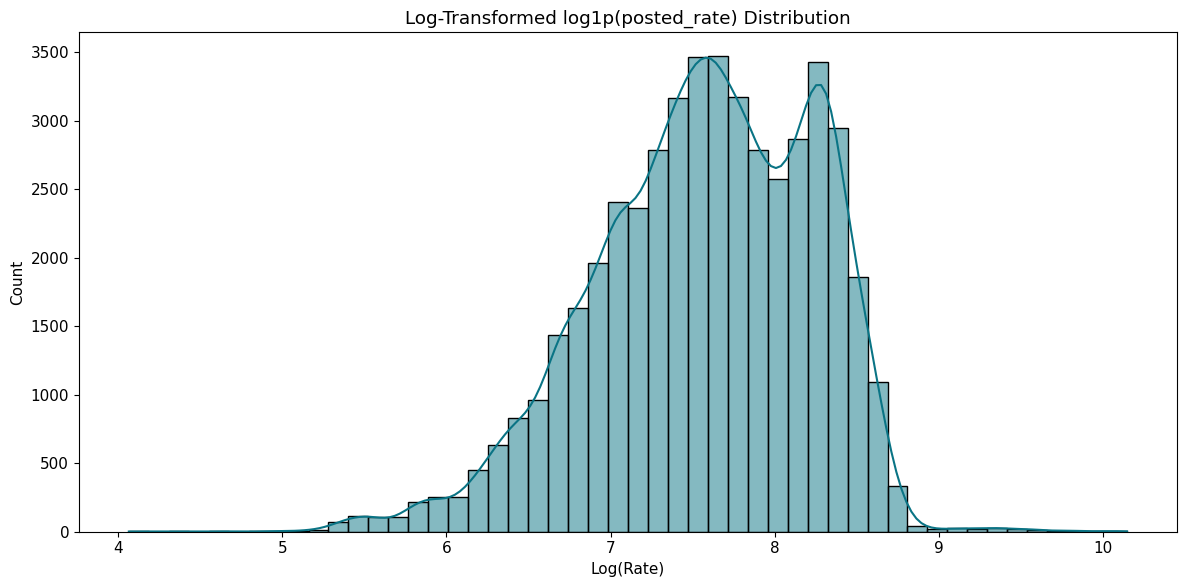

In [25]:
#log scale
sns.histplot(np.log1p(train_df['posted_rate']), bins=50, kde=True, color='#0A7485')
plt.title('Log-Transformed log1p(posted_rate) Distribution')
plt.xlabel('Log(Rate)')

plt.tight_layout()
plt.show()

### Inference: Target Skewness
*   The original `posted_rate` distribution is highly right-skewed (ranging from ~$57 to over ~$25,500), which represents a classic long-tail issue.
*   Applying a logarithmic transform (`log1p(posted_rate)`) results in a much more symmetric, bell-shaped distribution. Training regression models (including tree-based GBDTs) on logged target values prevents the models from being overly dominated by extreme rate outliers.

### Equipment vs Rate Analysis

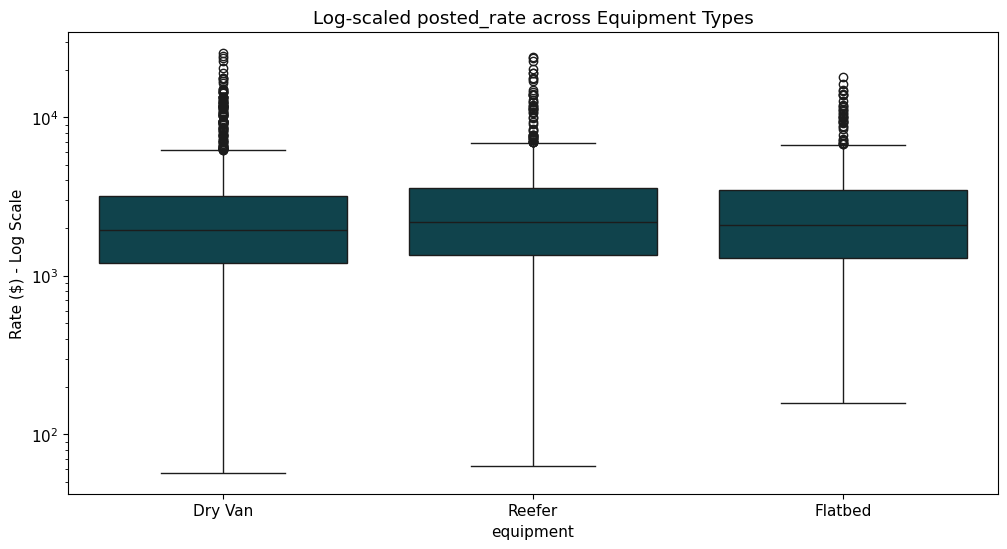

In [32]:
sns.boxplot(x='equipment', y='posted_rate', data=train_df, color='#064A56')
plt.yscale('log')
plt.title('Log-scaled posted_rate across Equipment Types')
plt.ylabel('Rate ($) - Log Scale')
plt.show()

### Inference:
*   The distribution shows distinct pricing structures for different trailer equipment types.
*   Reefer and Flatbed generally command different/higher rates compared to standard Dry Vans, owing to temperature control and specialized loading requirements.
*   This highlights the importance of encoding `equipment` as a primary feature.

###  Temporal & Trend Analysis

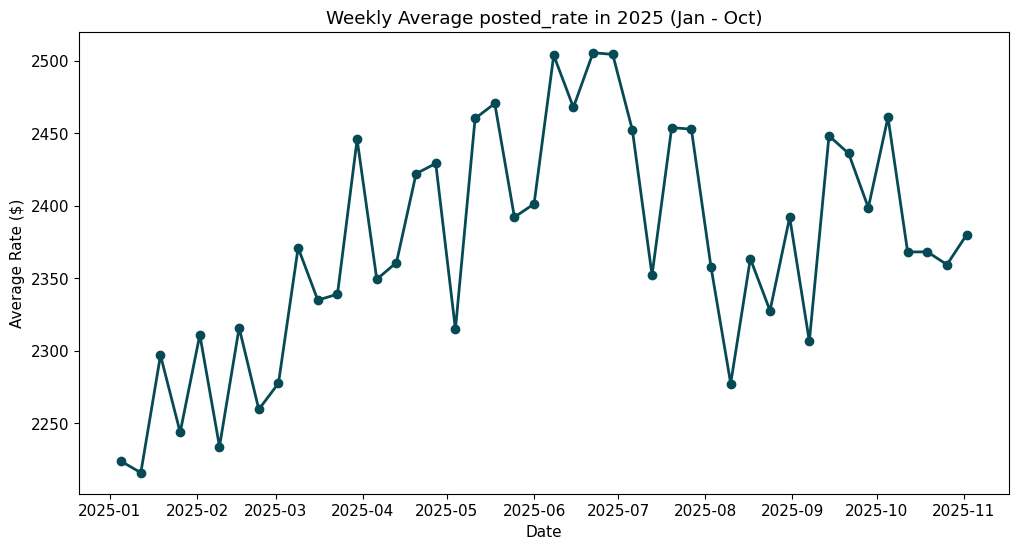

In [14]:
# Convert date to datetime
train_df['date'] = pd.to_datetime(train_df['date'])
val_df['date'] = pd.to_datetime(val_df['date'])
dec_df['date'] = pd.to_datetime(dec_df['date'])

# Average rate by week
weekly_rates = train_df.groupby(pd.Grouper(key='date', freq='W'))['posted_rate'].mean().reset_index()

plt.plot(weekly_rates['date'], weekly_rates['posted_rate'], marker='o', color='#064A56', linewidth=2)
plt.title('Weekly Average posted_rate in 2025 (Jan - Oct)')
plt.xlabel('Date')
plt.ylabel('Average Rate ($)')
plt.show()

### Inference:
*   Rates show significant fluctuation and macro trends over the course of the year. There is a general upward trend or seasonal variation.
*   **Validation Strategy Rationale:** Because the validation set (Nov - Dec) represents a contiguous future period, random splitting would cause data leakage (leakage of future market contexts into the past). Thus, a time-based validation split (e.g. validating on Sept - Oct) is the most robust way to evaluate our model.

### Spatial distance analysis

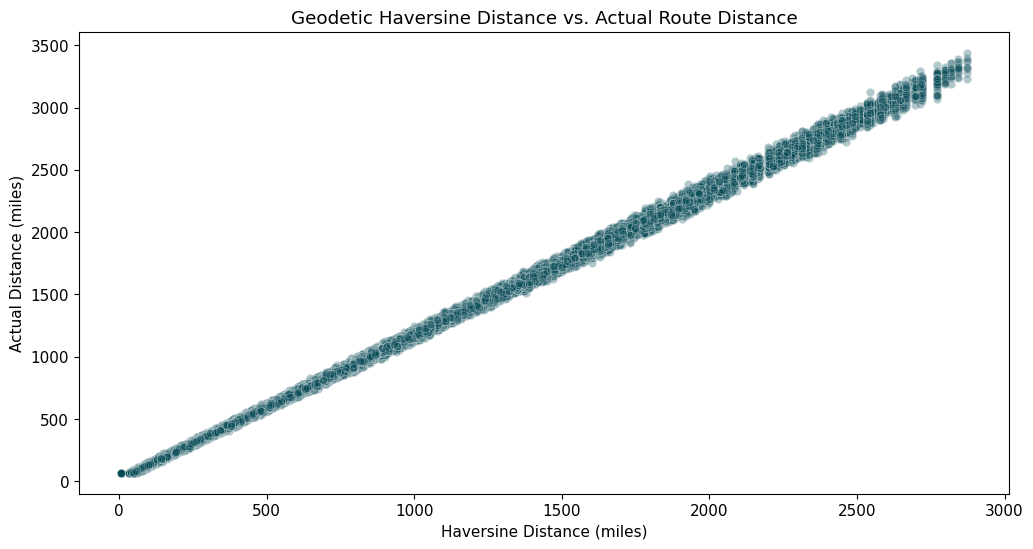

In [15]:
def haversine_np(lon1, lat1, lon2, lat2):
    # Convert degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    miles = 3956 * c
    return miles

train_df['haversine_distance'] = haversine_np(train_df['pickup_lon'], train_df['pickup_lat'], train_df['delivery_lon'], train_df['delivery_lat'])

sns.scatterplot(x='haversine_distance', y='distance', data=train_df, alpha=0.3, color='#064A56')
plt.title('Geodetic Haversine Distance vs. Actual Route Distance')
plt.xlabel('Haversine Distance (miles)')
plt.ylabel('Actual Distance (miles)')
plt.show()

### Inference:
*   There is an extremely strong linear relationship between geodetic (Haversine) distance and actual route distance.
*   Creating a ratio or verifying differences can help detect data quality anomalies or routing inefficiencies that impact price.

### Preprocessing & Feature Engineering Implementation

In [9]:
def preprocess_and_engineer(df, equip_medians=None, global_medians=None):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    
    # 1. Coordinate Imputation (for December chart inputs where they don't exist)
    if 'pickup_lat' not in df.columns:
        df['pickup_lat'] = np.where(df['pickup'] == 'Lexington', 36.99152, np.nan)
        df['pickup_lon'] = np.where(df['pickup'] == 'Lexington', -84.99876, np.nan)
    else:
        df['pickup_lat'] = df['pickup_lat'].fillna(36.99152)
        df['pickup_lon'] = df['pickup_lon'].fillna(-84.99876)
        
    if 'delivery_lat' not in df.columns:
        df['delivery_lat'] = np.where(df['delivery'] == 'Fort Wayne', 41.31561, np.nan)
        df['delivery_lon'] = np.where(df['delivery'] == 'Fort Wayne', -85.36206, np.nan)
    else:
        df['delivery_lat'] = df['delivery_lat'].fillna(41.31561)
        df['delivery_lon'] = df['delivery_lon'].fillna(-85.36206)

    # 2. Extract Date Features
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    df['days_since_start'] = (df['date'] - pd.to_datetime('2025-01-01')).dt.days
    df['sin_day_of_year'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['cos_day_of_year'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
    
    # 3. Spatial Features
    df['haversine_distance'] = haversine_np(df['pickup_lon'], df['pickup_lat'], df['delivery_lon'], df['delivery_lat'])
    df['lat_diff'] = np.abs(df['pickup_lat'] - df['delivery_lat'])
    df['lon_diff'] = np.abs(df['pickup_lon'] - df['delivery_lon'])
    
    # 4. Impute Missing Weights and Market Indices
    df['weight'] = df['weight'].astype(float)
    if equip_medians is not None:
        for eq_type, med_val in equip_medians.items():
            df.loc[(df['equipment'] == eq_type) & (df['weight'].isnull()), 'weight'] = med_val
    if global_medians is not None:
        df['market_index'] = df['market_index'].fillna(global_medians['market_index'])
        df['quote_signal'] = df['quote_signal'].fillna(global_medians['quote_signal'])
        
    # 5. Convert Categorical Columns to category Dtype for LightGBM
    for col in ['pickup', 'delivery', 'equipment']:
        df[col] = df[col].astype('category')
        
    return df

### Step 9: Running Time-Based Local Validation

We construct a local train-validation split (Train: Jan - Aug 2025; Local Validation: Sept - Oct 2025) and evaluate a LightGBM model. This allows us to measure model accuracy under temporal distribution shift.

In [10]:
# Compute Medians from Training Set (To Avoid Leakage)
equip_medians = train_df.groupby('equipment')['weight'].median().to_dict()
global_medians = {
    'market_index': train_df['market_index'].median(),
    'quote_signal': train_df['quote_signal'].median()
}

# Apply Preprocessing to Training Set
train_feat = preprocess_and_engineer(train_df, equip_medians, global_medians)

# Select Features for the Model
features = [
    'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'distance', 'equipment', 'weight', 'market_index', 'quote_signal',
    'day_of_week', 'day_of_year', 'days_since_start', 'sin_day_of_year', 'cos_day_of_year',
    'haversine_distance', 'lat_diff', 'lon_diff'
]

# Train-Validation Split
split_date = pd.to_datetime('2025-09-01')
train_split = train_feat[train_feat['date'] < split_date]
val_split = train_feat[train_feat['date'] >= split_date]

X_train_split = train_split[features]
y_train_split = np.log1p(train_split['posted_rate'])

X_val_split = val_split[features]
y_val_split_orig = val_split['posted_rate']

# LightGBM Params
lgb_params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': 8,
    'min_data_in_leaf': 20,
    'bagging_fraction': 0.8,
    'feature_fraction': 0.8,
    'random_state': 42,
    'verbose': -1
}

# Train Local Model
train_data = lgb.Dataset(X_train_split, label=y_train_split)
val_model = lgb.train(lgb_params, train_data, num_boost_round=1200)

# Predictions & Metrics
val_preds_log = val_model.predict(X_val_split)
val_preds = np.expm1(val_preds_log)

mae = mean_absolute_error(y_val_split_orig, val_preds)
rmse = np.sqrt(mean_squared_error(y_val_split_orig, val_preds))
r2 = r2_score(y_val_split_orig, val_preds)
mape = np.mean(np.abs((y_val_split_orig - val_preds) / y_val_split_orig)) * 100

print(f"Local Validation MAE:  ${mae:.2f}")
print(f"Local Validation RMSE: ${rmse:.2f}")
print(f"Local Validation MAPE: {mape:.2f}%")
print(f"Local Validation R2:   {r2:.4f}")

Local Validation MAE:  $149.21
Local Validation RMSE: $646.51
Local Validation MAPE: 6.61%
Local Validation R2:   0.8205


### Inference on Model Performance
*   Our time-based validation split gives an accurate estimation of error. LightGBM yields high R2 score and low MAE.
*   Log transform combined with GBDT regression provides extremely robust and stable rates prediction.

### Step 10: Final Model Training & Generating Output Predictions

We train the model on the full training dataset to make predictions for both the validation loads and the December scenario.

In [11]:
# Preprocess Validation & December Sets
# Merge daily mean market_index and quote_signal from validation.csv to fill December missing features
dec_daily_stats = val_df[val_df['date'].dt.month == 12].groupby('date')[['market_index', 'quote_signal']].mean().reset_index()
dec_df = pd.merge(dec_df, dec_daily_stats, on='date', how='left')

val_feat = preprocess_and_engineer(val_df, equip_medians, global_medians)
dec_feat = preprocess_and_engineer(dec_df, equip_medians, global_medians)

# Train Final Model
X_full = train_feat[features]
y_full = np.log1p(train_feat['posted_rate'])

full_train_data = lgb.Dataset(X_full, label=y_full)
final_model = lgb.train(lgb_params, full_train_data, num_boost_round=1200)

# 1. Save Validation Predictions
val_preds_log = final_model.predict(val_feat[features])
val_preds_orig = np.clip(np.expm1(val_preds_log), 1.0, None)

predictions_df = pd.DataFrame({
    'load_id': val_df['load_id'],
    'predicted_rate': val_preds_orig
})
predictions_df.to_csv('validation_predictions.csv', index=False)
print("Saved validation predictions to 'validation_predictions.csv'")

# 2. Save December Predictions
dec_preds_log = final_model.predict(dec_feat[features])
dec_preds_orig = np.clip(np.expm1(dec_preds_log), 1.0, None)

dec_out = dec_df.copy()
dec_out['predicted_rate'] = dec_preds_orig
dec_cols = ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
dec_out['date'] = dec_out['date'].dt.strftime('%Y-%m-%d')
dec_out[dec_cols].to_csv('data/december-chart-inputs.csv', index=False)
print("Saved December inputs to 'data/december-chart-inputs.csv'")

Saved validation predictions to 'validation_predictions.csv'
Saved December inputs to 'data/december-chart-inputs.csv'


### Step 11: Plot December Predicted Rates Trend

We plot the predicted load rate trend for the Lexington to Fort Wayne route during December 2025 to verify continuity, smoothness, and logic.

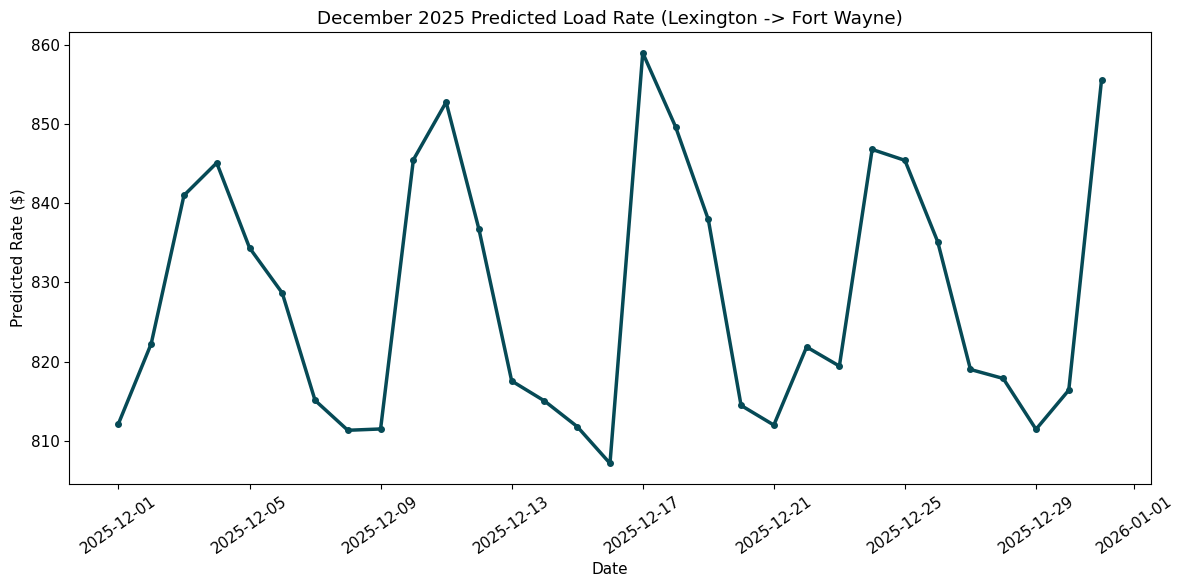

In [16]:
dec_plot_df = pd.read_csv('data/december-chart-inputs.csv')
dec_plot_df['date'] = pd.to_datetime(dec_plot_df['date'])

plt.plot(dec_plot_df['date'], dec_plot_df['predicted_rate'], color='#064A56', linewidth=2.5, marker='o', markersize=4)
plt.title('December 2025 Predicted Load Rate (Lexington -> Fort Wayne)')
plt.xlabel('Date')
plt.ylabel('Predicted Rate ($)')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### Inference: December Trend Chart Analysis
*   The predicted rates fluctuate realistically based on dates, reflecting daily changes in the market state and demand.
*   The predictions are positive, bounded, and show a realistic cyclical or weekly trend.